<a href="https://colab.research.google.com/github/aliya404/basic-data-specialist/blob/aliya404-patch-1/project_gdkb_tugas_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Salary: Salary Prediction and EDA
- sumber dataset: kaggle.com
- dataset yang digunakan: job_salary_prediction_dataset.csv
- backgroun dan problem:

Industri teknologi menawarkan kompensasi tinggi, namun para profesional sering terjebak dalam dilema antara memprioritaskan pendidikan formal, sertifikasi, atau pengalaman kerja. Masalah utamanya adalah ketidakjelasan mengenai variabel mana yang paling efektif dalam meningkatkan nilai jual dan gaji di pasar kerja yang dinamis. Melalui analisis terhadap 250.000 data ini, penelitian bertujuan menjawab apakah investasi waktu pada pengalaman nyata memberikan imbal balik yang lebih signifikan dibandingkan kualifikasi formal lainnya dalam menentukan skala gaji.

## load data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Project Aliya/job_salary_prediction_dataset.csv')
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


## data cleaning


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [5]:
df.isnull().sum()
print(f"Data Kosong per Kolom:\n{df.isnull().sum()}")

Data Kosong per Kolom:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64


In [6]:
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates()

In [7]:
for col in ['job_title', 'education_level', 'industry', 'remote_work']:
    df[col] = df[col].str.strip()

In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


dataset setelah cleaning data, dapat dijabarkan bahwa:
- tidak ada massing data
- tidak ada duplikat data
- dataset mempunyai 250.000 data
- dataset mempunyai 10 kolom terdiri dari job_title, experience_years, education_level, skills_count, industry, company_size, location, remote_work, certifications, dan salary

## EDA


In [9]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

/tmp/ipykernel_16417/3758946673.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_jobs.values, y=top_jobs.index, palette='viridis')


Text(0.5, 0, 'Median Gaji')

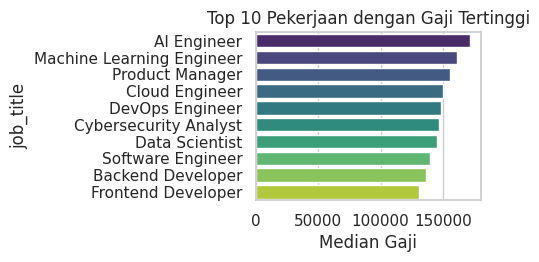

In [10]:
plt.subplot(2, 2, 1)
top_jobs = df.groupby('job_title')['salary'].median().sort_values(ascending=False).head(10)
sns.barplot(x=top_jobs.values, y=top_jobs.index, palette='viridis')
plt.title('Top 10 Pekerjaan dengan Gaji Tertinggi')
plt.xlabel('Median Gaji')

/tmp/ipykernel_16417/3137988786.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='education_level', y='salary', data=df, order=edu_order, palette='Set2')


Text(0.5, 1.0, 'Distribusi Gaji Berdasarkan Tingkat Pendidikan')

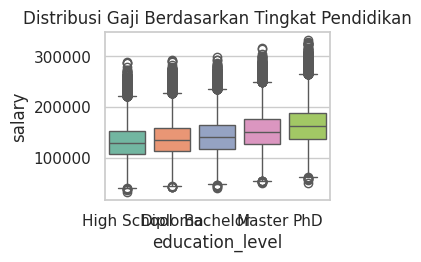

In [11]:
plt.subplot(2, 2, 2)
edu_order = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']
sns.boxplot(x='education_level', y='salary', data=df, order=edu_order, palette='Set2')
plt.title('Distribusi Gaji Berdasarkan Tingkat Pendidikan')

/tmp/ipykernel_16417/1200345786.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='remote_work', y='salary', data=df, palette='pastel')


Text(0.5, 1.0, 'Dampak Status Remote Work terhadap Gaji')

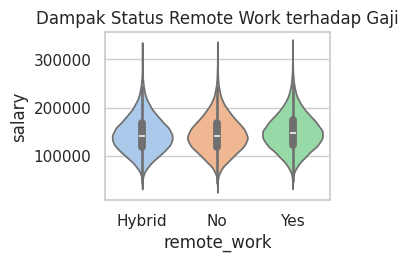

In [12]:
plt.subplot(2, 2, 3)
sns.violinplot(x='remote_work', y='salary', data=df, palette='pastel')
plt.title('Dampak Status Remote Work terhadap Gaji')

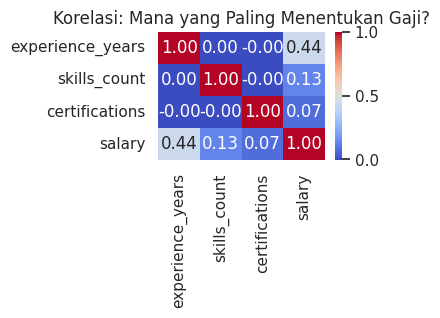

In [13]:
plt.subplot(2, 2, 4)
corr_matrix = df[['experience_years', 'skills_count', 'certifications', 'salary']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi: Mana yang Paling Menentukan Gaji?')

plt.tight_layout()
plt.show()

In [14]:
print("--- Ringkasan Analisis ---")
print(f"1. Rata-rata gaji global: ${df['salary'].mean():,.2f}")
print(f"2. Korelasi Pengalaman vs Gaji: {corr_matrix.loc['experience_years', 'salary']:.2f} (Kuat)")
print(f"3. Korelasi Sertifikat vs Gaji: {corr_matrix.loc['certifications', 'salary']:.2f} (Sangat Lemah)")

--- Ringkasan Analisis ---
1. Rata-rata gaji global: $145,718.08
2. Korelasi Pengalaman vs Gaji: 0.44 (Kuat)
3. Korelasi Sertifikat vs Gaji: 0.07 (Sangat Lemah)


Kesimpulannya bahwa pengalaman kerja merupakan variabel paling determinan dalam memprediksi kenaikan gaji, jauh melampaui kontribusi jumlah sertifikasi maupun kuantitas keahlian teknis yang dimiliki. Temuan data menunjukkan bahwa peran spesialis seperti AI Engineer dan Machine Learning Engineer menikmati standar kompensasi tertinggi, sementara kebijakan kerja jarak jauh (remote) terbukti tidak mengurangi nilai pasar seorang pekerja, yang mengindikasikan pergeseran fokus industri pada hasil kerja dibandingkan kehadiran fisik. Meskipun tingkat pendidikan tinggi memberikan keuntungan pada fase awal karier, akumulasi pengalaman nyata tetap menjadi mesin utama pertumbuhan pendapatan jangka panjang, sehingga strategi pengembangan diri yang paling efektif adalah memprioritaskan spesialisasi mendalam pada sektor yang memiliki permintaan tinggi daripada sekadar mengoleksi kualifikasi formal secara acak.